In [8]:
import sys
sys.path.insert(0, "..")

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import torch

from src.data import load_california_housing
from src.models import make_gp, train_mlp
from src.methods import mc_dropout_predict, train_ensemble, ensemble_predict, laplace_predict, train_vi, vi_predict
from src.plotting import plot_sorted_predictions, plot_predicted_vs_true
from src.metrics import summary

np.random.seed(42)
torch.manual_seed(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data

In [9]:
X_train, y_train, X_test, y_test, _ = load_california_housing()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (2000, 8), Test: (4128, 8)


## Gaussian Process

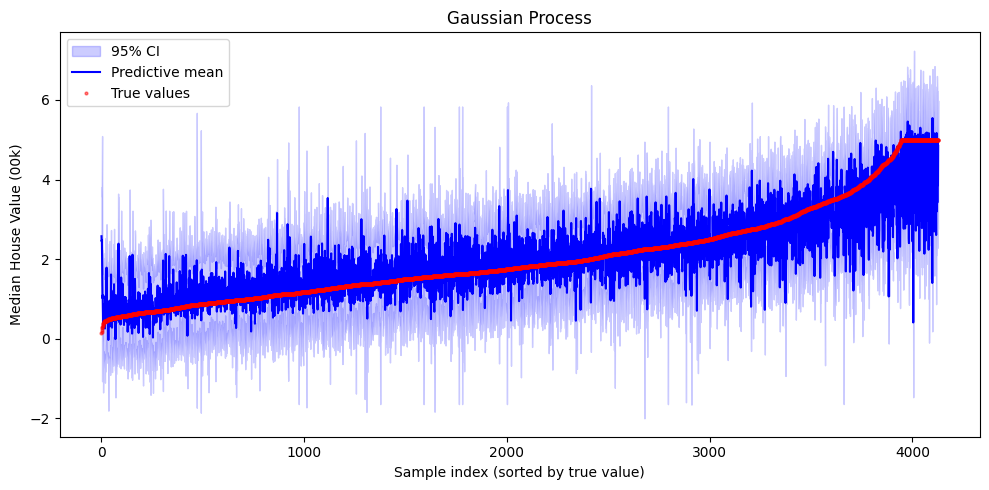

In [10]:
gp = make_gp().fit(X_train, y_train)
gp_mean, gp_std = gp.predict(X_test, return_std=True)
plot_sorted_predictions(y_test, gp_mean, gp_std, "Gaussian Process", "Median House Value (00k)")

## Monte Carlo Dropout
Gal & Ghahramani 2016.

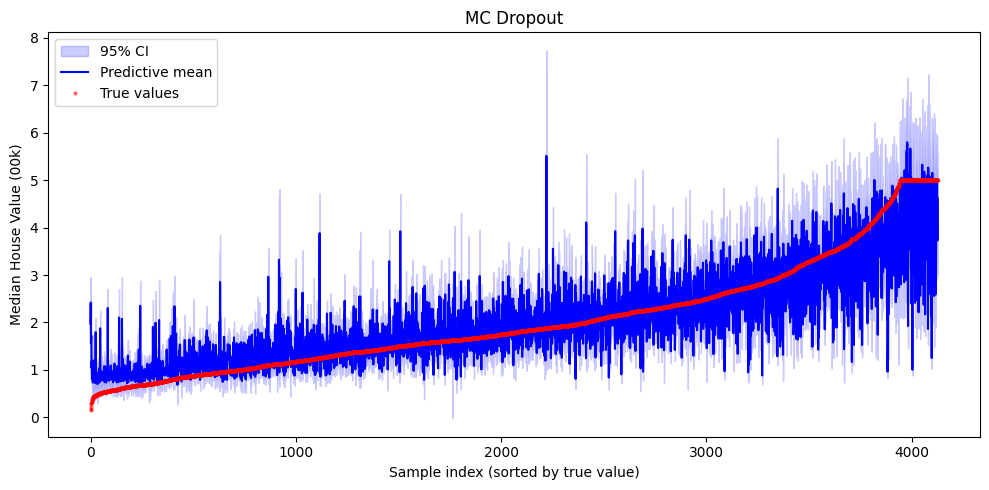

In [11]:
nn_dropout = train_mlp(X_train, y_train, dropout=0.2, epochs=1000)
mc_mean, mc_std = mc_dropout_predict(nn_dropout, X_test, n_samples=200)
plot_sorted_predictions(y_test, mc_mean, mc_std, "MC Dropout", "Median House Value (00k)")

## Deep Ensemble
Lakshminarayanan et al. 2017.

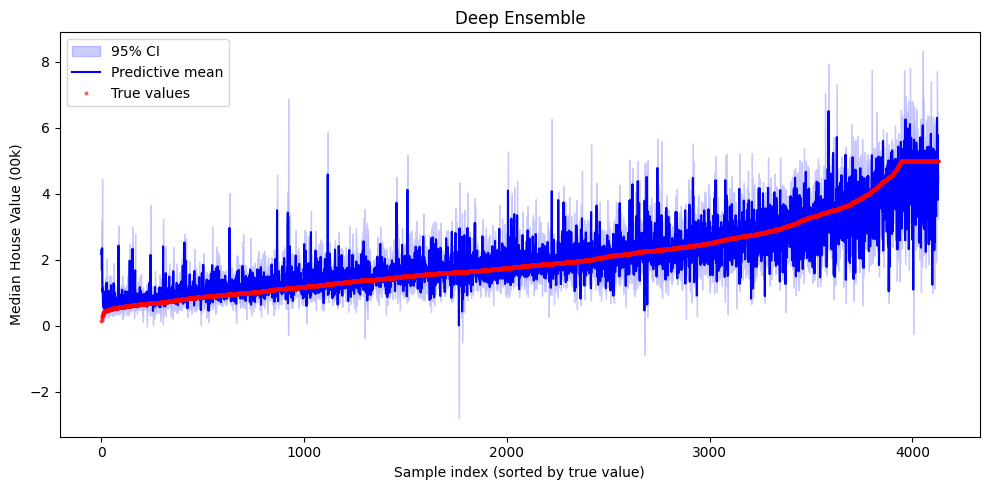

In [12]:
ensemble = train_ensemble(X_train, y_train, n_models=5, epochs=1000)
ens_mean, ens_std = ensemble_predict(ensemble, X_test)
plot_sorted_predictions(y_test, ens_mean, ens_std, "Deep Ensemble", "Median House Value (00k)")

## Laplace Approximation
Post-hoc aproksymacja na ostatniej warstwie MLP.

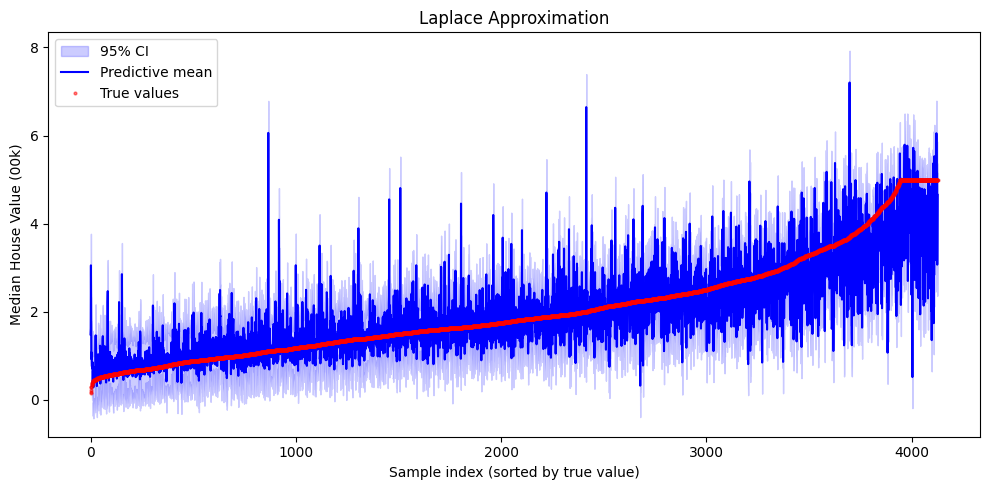

In [ ]:
#TODO : użyć gotowej bilbioteki 

nn_laplace = train_mlp(X_train, y_train, epochs=1000)
la_mean, la_std = laplace_predict(nn_laplace, X_train, y_train, X_test)
plot_sorted_predictions(y_test, la_mean, la_std, "Laplace Approximation", "Median House Value (00k)")

## Variational Inference
Bayes by Backprop (Blundell et al. 2015).

In [ ]:
#TODO : do popraw/usuniecia
vi_model = train_vi(X_train, y_train, epochs=1000)
vi_mean, vi_std = vi_predict(vi_model, X_test, n_samples=200)
plot_sorted_predictions(y_test, vi_mean, vi_std, "Variational Inference", "Median House Value ($100k)")

## Predicted vs True

In [ ]:
plot_predicted_vs_true(
    y_test,
    means  = [gp_mean,  mc_mean,  ens_mean, la_mean,  vi_mean],
    stds   = [gp_std,   mc_std,   ens_std,  la_std,   vi_std],
    titles = ["GP", "MC Dropout", "Deep Ensemble", "Laplace", "VI (BbB)"],
    ylabel = "Median House Value ($100k)",
)

## Metrics

In [14]:
results = {
    "GP":            summary(y_test, gp_mean,  gp_std),
    "MC Dropout":    summary(y_test, mc_mean,  mc_std),
    "Deep Ensemble": summary(y_test, ens_mean, ens_std),
    "Laplace":       summary(y_test, la_mean,  la_std),
    "VI (BbB)":      summary(y_test, vi_mean,  vi_std),
}
pd.DataFrame(results).T.round(4)

,RMSE,MAE,NLL,PICP,MPIW
GP,0.5860,0.4166,0.8710,0.9455,2.3108
MC Dropout,0.5596,0.3826,4.0954,0.6063,0.8246
Deep Ensemble,0.5644,0.3804,5.4200,0.5865,0.7799
Laplace,0.6286,0.4198,1.4080,0.8290,1.4118
